In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
!pip install iminuit
!pip install
from iminuit import Minuit


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip
ERROR: You must give at least one requirement to install (see "pip help install")


In [5]:
import os

path = "../DMSO"
all_files = os.listdir(path)
csv_files = [f for f in all_files if f.endswith('.csv')]

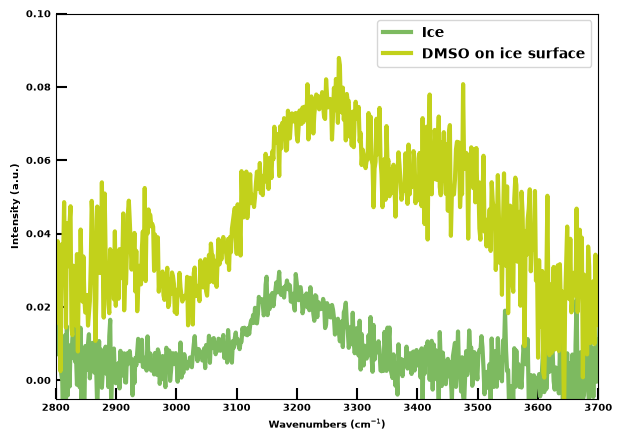

In [23]:
file_data = {
    'ice_ssp_3um_300s_a.csv': 'Ice',
    'ice_dmso_ssp_3um_600s_b.csv': 'DMSO on ice surface'
}

plt.figure(figsize=(7, 5))
plt.ylim(-0.005, 0.1) # Adjusted y-limit to accommodate both datasets
plt.xlim(2800, 3700)
plt.xticks(fontsize=7, fontweight='bold')
plt.yticks(fontsize=7, fontweight='bold')
plt.xlabel(r'Wavenumbers (cm$^{-1}$)', fontsize=7, fontweight='bold')
plt.ylabel('Intensity (a.u.)', fontsize=7, fontweight='bold')
#plt.title('Ice and DMSO on ice surface', fontsize=15, fontweight='bold')

# borders
ax = plt.gca()
#ax.spines['top'].set_linewidth(2.5)
#ax.spines['right'].set_linewidth(2.5)
#ax.spines['left'].set_linewidth(2)
#ax.spines['bottom'].set_linewidth(2)

plt.grid(False)

for filename, label in file_data.items():
    file_path = os.path.join(path, filename)
    try:
        # read the CSV with comma as delimiter, treating the first row as header
        df = pd.read_csv(file_path, sep=',', header=0, engine='python')

        # convert 'Wavenumber' and 'Intensity' to numeric
        df['Wavenumber'] = pd.to_numeric(df['Wavenumber'], errors='coerce')
        df['Intensity'] = pd.to_numeric(df['Intensity'], errors='coerce')

        # drop rows where either 'Wavenumber' or 'Intensity' is NaN (inf?)
        df.dropna(subset=['Wavenumber', 'Intensity'], inplace=True)

        # axes names
        x_data = df['Wavenumber']
        y_data = df['Intensity']

        # create an offset and assign colors
        if label == 'DMSO on ice surface':
            y_data = y_data + 0.01
            plot_color = '#c2d11b'  # Set color for DMSO
        else:
            plot_color = '#7dba60'   # Set color for Ice

        if not df.empty:
            plt.plot(x_data, y_data, label=label, lw=3, color=plot_color) # Added color argument
        else:
            print(f"No valid numeric data found for plotting in {filename} after cleaning.")

    except Exception as e:
        print(f"Error reading or plotting {filename}: {e}. Please check file format and column names.")

plt.legend(prop={'size': 10, 'weight': 'bold'})
#plt.legend(prop={'size': 10, 'weight': 'bold'}, frameon=False, loc='upper left', bbox_to_anchor=(1, 1))
plt.tick_params(axis='both', direction='in', length=8, width=1.5)
plt.show()